In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
%matplotlib inline

import inversion_tools

In [38]:
# ------ read data
pdir = '/work/noaa/co2/jhollo/processed_transport_data/' 
data = inversion_tools.read_transport_jacobians_control('ocean', '2014-09-01', '2019-01-01', 
                                                        return_mf=False, processing_dir=pdir, 
                                                        quiet=True)

IndentationError: unexpected indent (1077530030.py, line 4)

In [ ]:
import inversion_tools
pdir = '/work/noaa/co2/jhollo/processed_transport_data/' 
data = inversion_tools.read_transport_jacobians_control('ocean', '2014-09-01', '2019-01-01', processing_dir=pdir)

In [39]:
# ------ get timeseries averaged on [-10, 10] deg in latitude
trop_data = data.sel(lat=slice(-5, 5), lon=slice(-170, -120))
lat     = trop_data.lat
weights = np.cos(np.deg2rad(lat))
weights.name = "weights"
trop_data_weighted = trop_data.weighted(weights)
trop_data_mean = trop_data_weighted.mean(('lat', 'lon'))

In [36]:
data.time[487]

<xarray.DataArray 'time' ()> Size: 8B
array('2016-01-01T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    lev      float64 8B 0.9925
    time     datetime64[ns] 8B 2016-01-01
Attributes:
    standard_name:  time
    long_name:      Time
    axis:           T

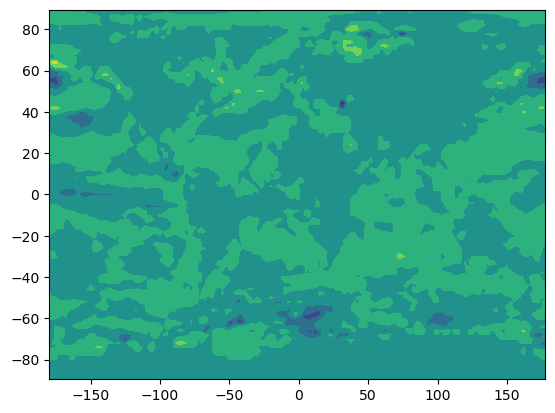

In [37]:

plt.contourf(data.lon, data.lat, data['residual'].isel(time=487))

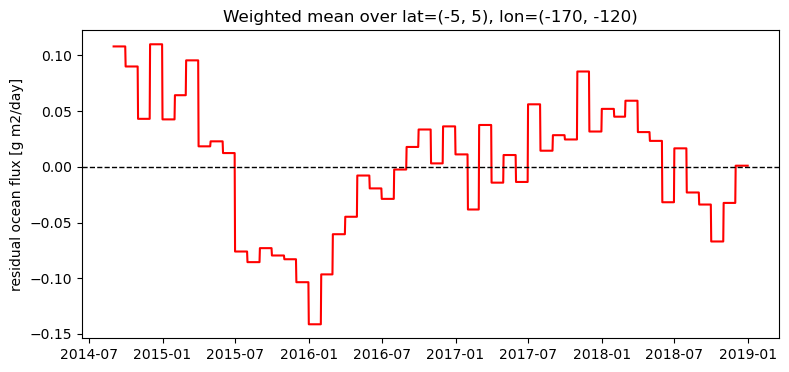

In [23]:
# ------ plot time series
y = trop_data_mean['residual']
x = trop_data_mean['residual'].time

fig = plt.figure(figsize=(9,4))
ax  = fig.add_subplot()
ax.plot(x, y, '-r')
ax.set_ylabel('residual ocean flux [g m2/day]')
ax.set_title('Weighted mean over lat=(-5, 5), lon=(-170, -120)')
ax.axhline(y=0, ls='--', color='k', lw=1)

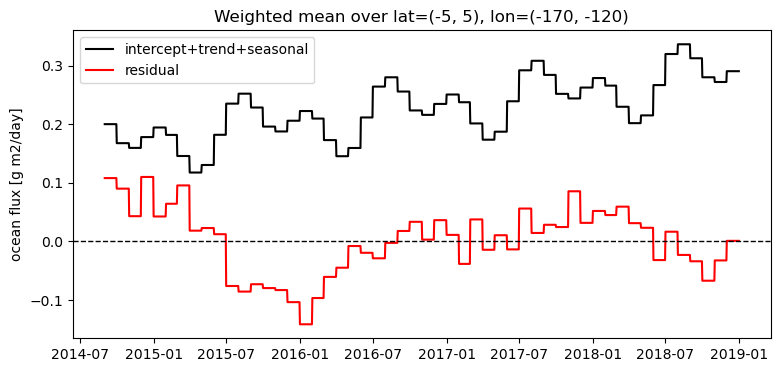

In [20]:
# ------ plot time series
tdm = trop_data_mean
y = tdm['intercept'] + tdm['trend'] + tdm['sin1'] + tdm['sin2'] + tdm['cos1'] + tdm['cos2'] + tdm['residual']
x = y.time

fig = plt.figure(figsize=(9,4))
ax  = fig.add_subplot()
ax.plot(x, y-tdm['residual'], '-k', label='intercept+trend+seasonal')
ax.plot(x, tdm['residual'], '-r', label='residual')
ax.set_ylabel('ocean flux [g m2/day]')
ax.legend()
ax.set_title('Weighted mean over lat=(-5, 5), lon=(-170, -120)')
ax.axhline(y=0, ls='--', color='k', lw=1)